# Phase 2 - Step 1: Load Data & Basic Info

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/creditcard.csv')

print(df.shape)
print(df.info())
df.head()

(284807, 31)
<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


# Step 2: Class Distribution Check

Class
0    284315
1       492
Name: count, dtype: int64
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


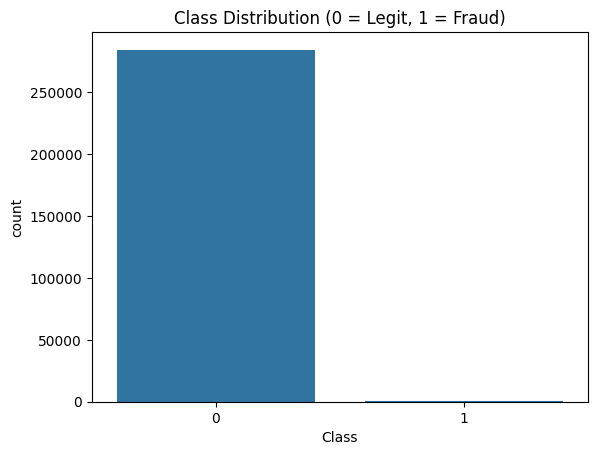

In [2]:
print(df['Class'].value_counts())
print(df['Class'].value_counts(normalize=True) * 100)

sns.countplot(x='Class', data=df)
plt.title('Class Distribution (0 = Legit, 1 = Fraud)')
plt.show()

# Step 3: Missing Values & Duplicates Check

In [3]:
# Missing values
print('Missing values per column:')
print(df.isnull().sum())
print('\nTotal missing values:', df.isnull().sum().sum())

# Duplicates
duplicate_count = df.duplicated().sum()
print('\nTotal duplicate rows:', duplicate_count)
print('Percentage of duplicates: {:.2f}%'.format((duplicate_count/len(df))*100))

Missing values per column:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Total missing values: 0



Total duplicate rows: 1081
Percentage of duplicates: 0.38%


# Step 4: Transaction Amount/Time Analysis & Outlier Analysis

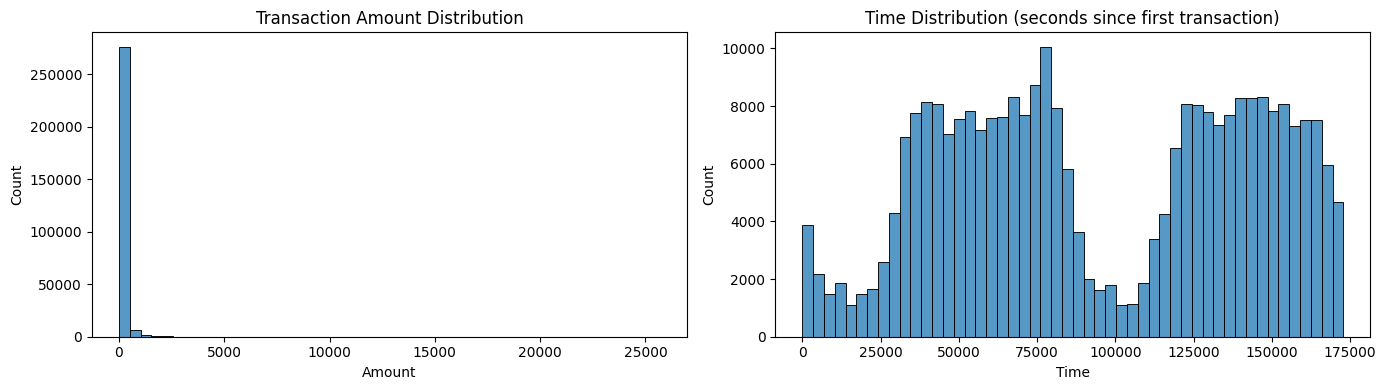

Amount stats for Legit transactions:
count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64

Amount stats for Fraud transactions:
count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64


In [4]:
# Amount and Time distribution
fig, ax = plt.subplots(1, 2, figsize=(14,4))
sns.histplot(df['Amount'], bins=50, ax=ax[0])
ax[0].set_title('Transaction Amount Distribution')

sns.histplot(df['Time'], bins=50, ax=ax[1])
ax[1].set_title('Time Distribution (seconds since first transaction)')
plt.tight_layout()
plt.show()

# Amount stats by class
print('Amount stats for Legit transactions:')
print(df[df['Class']==0]['Amount'].describe())
print('\nAmount stats for Fraud transactions:')
print(df[df['Class']==1]['Amount'].describe())

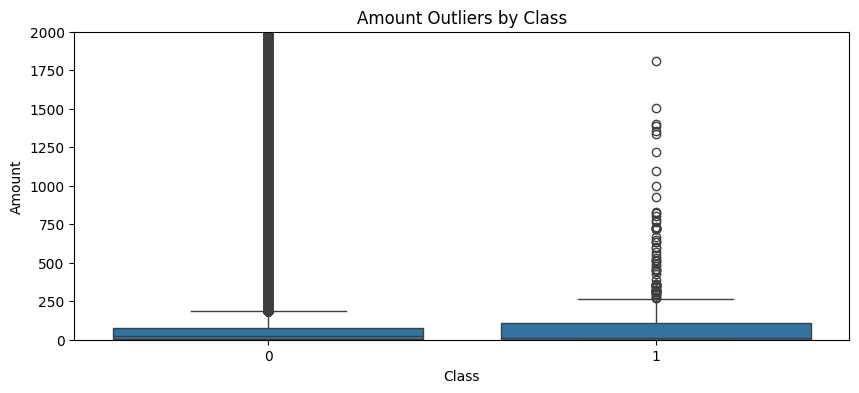

Number of Amount outliers (IQR method): 31904
Of those, fraud cases: 91


In [5]:
# Outlier analysis using boxplot for Amount
plt.figure(figsize=(10,4))
sns.boxplot(x='Class', y='Amount', data=df)
plt.title('Amount Outliers by Class')
plt.ylim(0, 2000)  # zoom in, since a few huge outliers exist
plt.show()

# IQR-based outlier count for Amount
Q1 = df['Amount'].quantile(0.25)
Q3 = df['Amount'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR
outliers = df[(df['Amount'] < lower) | (df['Amount'] > upper)]
print('Number of Amount outliers (IQR method):', len(outliers))
print('Of those, fraud cases:', outliers['Class'].sum())

# Step 5: Correlation Analysis & Data Leakage Investigation

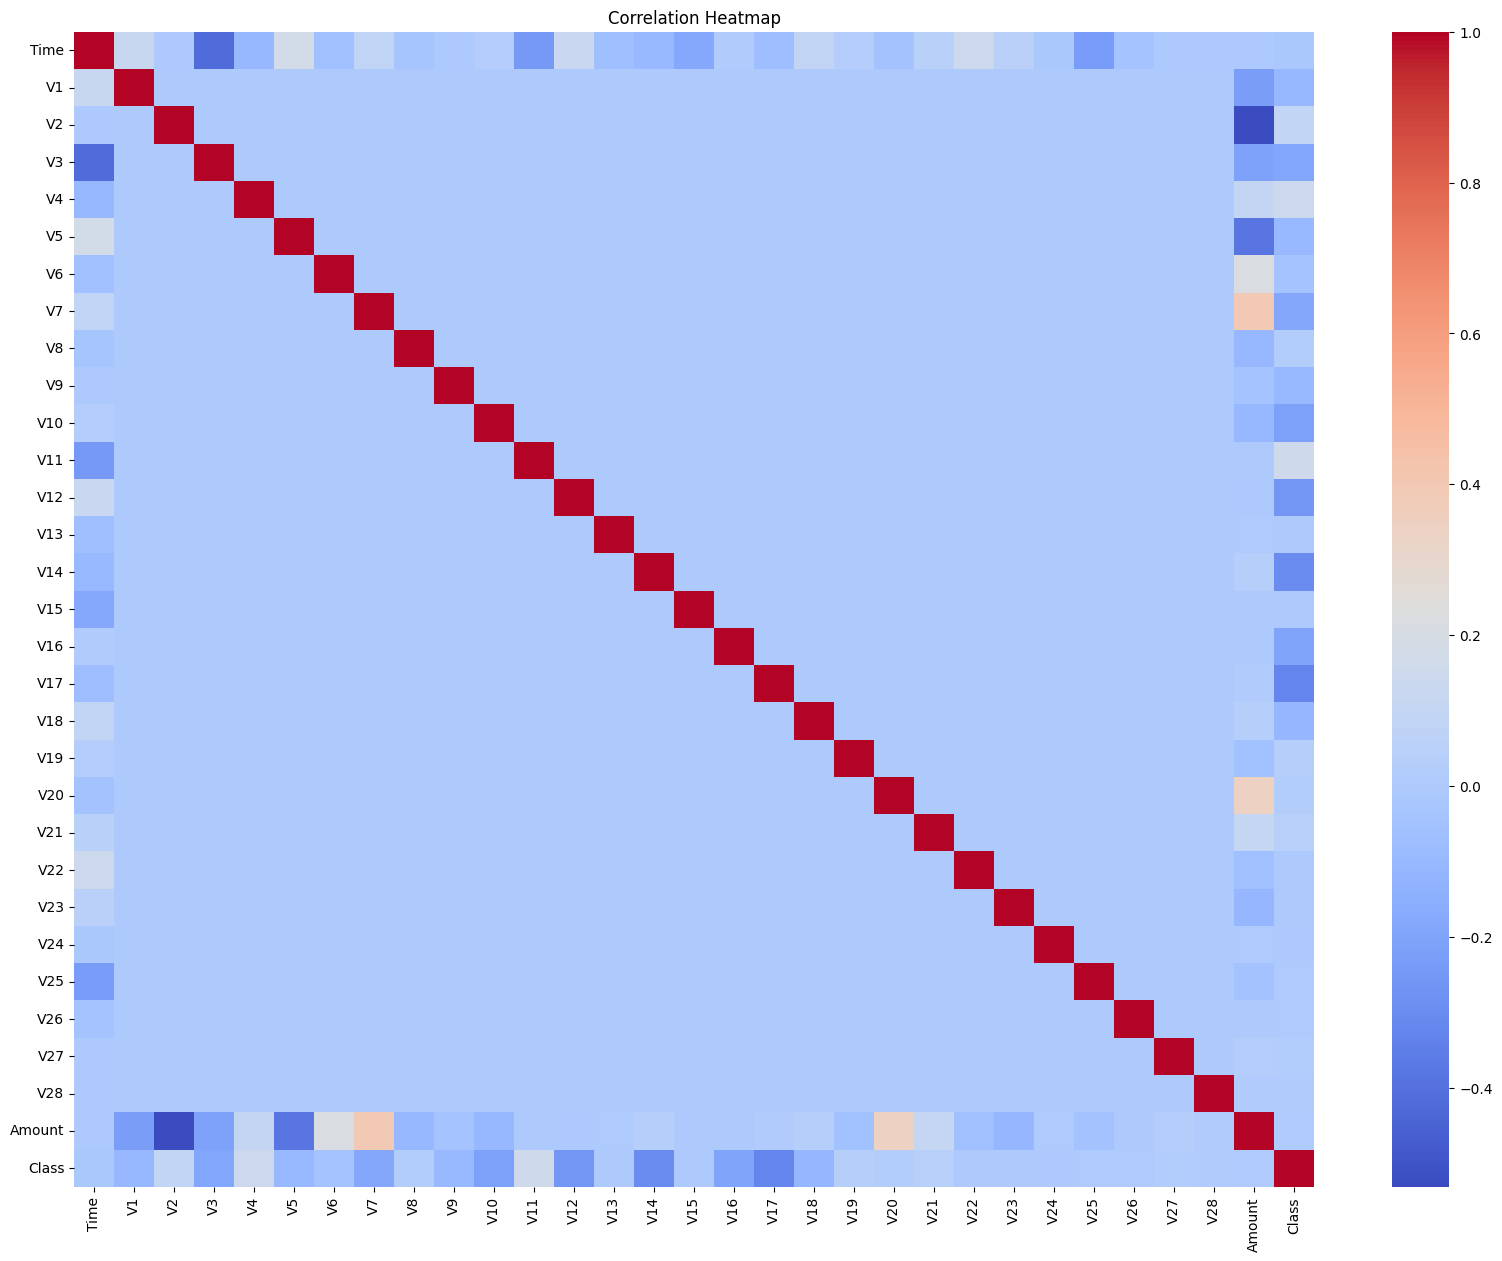

In [6]:
# Correlation heatmap (all features are PCA-transformed: V1-V28, plus Time, Amount, Class)
plt.figure(figsize=(20,15))
corr = df.corr()
sns.heatmap(corr, cmap='coolwarm', annot=False)
plt.title('Correlation Heatmap')
plt.show()

In [7]:
# Which features correlate most strongly with Class (fraud)?
class_corr = corr['Class'].sort_values(ascending=False)
print('Top features correlated with Class:')
print(class_corr)

Top features correlated with Class:
Class     1.000000
V11       0.154876
V4        0.133447
V2        0.091289
V21       0.040413
V19       0.034783
V20       0.020090
V8        0.019875
V27       0.017580
V28       0.009536
Amount    0.005632
V26       0.004455
V25       0.003308
V22       0.000805
V23      -0.002685
V15      -0.004223
V13      -0.004570
V24      -0.007221
Time     -0.012323
V6       -0.043643
V5       -0.094974
V9       -0.097733
V1       -0.101347
V18      -0.111485
V7       -0.187257
V3       -0.192961
V16      -0.196539
V10      -0.216883
V12      -0.260593
V14      -0.302544
V17      -0.326481
Name: Class, dtype: float64


In [8]:
# Data leakage investigation
# 1. Check if 'Time' or 'Amount' alone can perfectly separate classes (would indicate leakage)
print('Time range for fraud vs legit:')
print(df.groupby('Class')['Time'].describe())

# 2. Check for any duplicate rows that appear in both classes (label leakage)
dupes = df[df.duplicated(subset=df.columns.difference(['Class']), keep=False)]
conflicting = dupes.groupby(list(df.columns.difference(['Class'])))['Class'].nunique()
print('\nRows with identical features but different Class labels (leakage risk):', (conflicting > 1).sum())

# 3. Confirm no feature is a direct copy/proxy of Class (correlation == 1 or -1, excluding Class itself)
suspicious = class_corr[(class_corr.abs() > 0.9) & (class_corr.index != 'Class')]
print('\nFeatures suspiciously perfectly correlated with Class:', list(suspicious.index) if len(suspicious) > 0 else 'None found (good sign)')

Time range for fraud vs legit:
          count          mean           std    min      25%      50%  \
Class                                                                  
0      284315.0  94838.202258  47484.015786    0.0  54230.0  84711.0   
1         492.0  80746.806911  47835.365138  406.0  41241.5  75568.5   

            75%       max  
Class                      
0      139333.0  172792.0  
1      128483.0  170348.0  



Rows with identical features but different Class labels (leakage risk): 0

Features suspiciously perfectly correlated with Class: None found (good sign)
